In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

# Load dataset
df = pd.read_csv("C:\\Users\\Riya\\Downloads\\diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# RandomForest does not need scaling, so skip StandardScaler here

# Define parameter grid
param_dist = {
    'n_estimators': [100, 400],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5, 15],
    'min_samples_leaf': [4, 6],
    'max_features': ['sqrt']
}

# Base model with class_weight balanced
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
best_random_model = random_search.best_estimator_

# Predictions
y_pred_random = best_random_model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_random))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_random))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': 20}
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.76      0.80        99
           1       0.63      0.75      0.68        55

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154

Confusion Matrix:
 [[75 24]
 [14 41]]


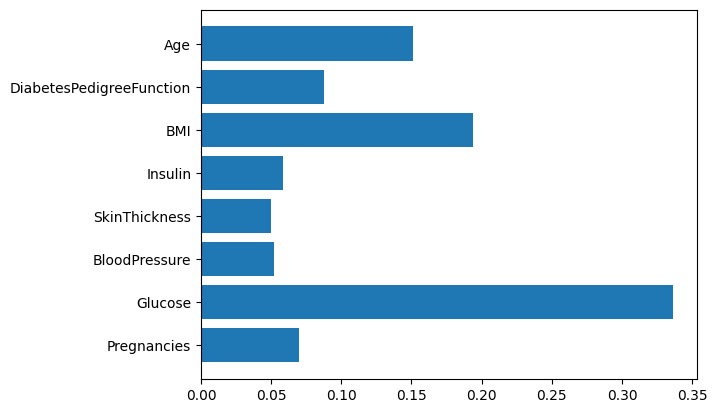

In [9]:
importances = best_random_model.feature_importances_

plt.barh(X.columns, importances)
plt.show()

In [10]:


# --- User Input Prediction ---
feature_names = X.columns.tolist()

def get_user_input():
    # pregnancies = 6
    # glucose = 148
    # bp = 72
    # skin = 35
    # insulin = 0
    # bmi = 33.6
    # dpf = 0.627
    # age = 50
     pregnancies = float(input("Pregnancies: "))
     glucose = float(input("Glucose: "))
     bp = float(input("Blood Pressure: "))
     skin = float(input("Skin Thickness: "))
     insulin = float(input("Insulin: "))
     bmi = float(input("BMI: "))
     dpf = float(input("Diabetes Pedigree Function: "))
     age = float(input("Age: "))
     return [pregnancies, glucose, bp, skin, insulin, bmi, dpf, age]

user_data = get_user_input()
user_df = pd.DataFrame([user_data], columns=feature_names)

prediction = best_random_model.predict(user_df)[0]

if prediction == 0:
    print("The person is not diabetic")
else:
    print("The person has diabetes")




Pregnancies:  6
Glucose:  78
Blood Pressure:  78
Skin Thickness:  56
Insulin:  78
BMI:  5
Diabetes Pedigree Function:  5
Age:  90


The person is not diabetic


In [12]:
import joblib
joblib.dump(best_random_model, "diabetes_model.pkl")
loaded_model = joblib.load("diabetes_model.pkl")
y_pred_loaded = loaded_model.predict(X_test)

print("Loaded model predictions match:", (y_pred_random== y_pred_loaded).all())
# joblib.dump(scaler,"scaler.pkl")



Loaded model predictions match: True
